# Visualização de carregamento máximo de uma Linha de Transmissão Aérea

Emprego de fasores para visualizar os limites de carregamento

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import ipywidgets as widgets
from IPython.display import display


In [2]:

# ----------------------------
# Transmission Line Parameters
# ----------------------------
# Series impedance per unit length [Ohm/km]
z = 0.1018 + 1j * 0.4894
# Shunt admittance per unit length [S/km] (purely imaginary, per your last snippet)
y = 1j * 3.3753e-6

# Propagation constant and characteristic impedance (at 1 km)
Gamma = np.sqrt(z * y)   # 1/km
Zc = np.sqrt(z / y)      # Ohm

# Nominal voltage [V] and natural power [W]
Vn = 230.0e3
Pn = Vn**2 / Zc.real

# Nominal conductor current [A]
inom = 640.0



In [3]:

# ----------------------------
# Core calculations and plotting
# ----------------------------
def abcd_params(z, y, x_km):
    gamma = np.sqrt(z * y)  # 1/km
    zc = np.sqrt(z / y)     # Ohm
    gx = gamma * x_km
    a = np.cosh(gx)
    s = np.sinh(gx)
    b = zc * s
    c = (1.0 / zc) * s
    return gamma, zc, a, b, c

def qLT_plot(ax, icb, z, y, x_km, Vb, Vr=1.0, pn=1.0, fp=1.0, i_sign=-1):
    """
    Draw the phasor diagram (replicates your qLT[]).
    Returns a dict of computed values.
    """
    # Transmission line constants and ABCD
    gamma, zc, a, b, c = abcd_params(z, y, x_km)

    # Base power (p = Vb^2 / Re[zc])
    p_base = Vb**2 / zc.real

    # Receiving-end conditions
    vr = Vr * Vb
    sr_mag = (p_base * pn) / fp
    # Matches Wolfram sign convention in qLT: sr = sr * Exp[-i*I*ArcCos[fp]]
    sr = sr_mag * np.exp(-i_sign * 1j * np.arccos(fp))
    ir = np.conj(sr) / (np.sqrt(3.0) * vr)

    # Sending-end calculations
    vs = a * vr + b * ir
    is_ = c * vr + a * ir

    # Normalized for plotting
    vsr = vs.real / Vb
    vsi = vs.imag / Vb
    isr = is_.real / icb
    isi = is_.imag / icb

    # Magnitudes and angles
    vsAbs = np.abs(vs / Vb)                  # p.u.
    vsArg = np.degrees(np.angle(vs))         # deg
    isAbs = np.abs(is_)                      # A
    isArg = np.degrees(np.angle(is_))        # deg

    # Dynamic scaling for current vector
    maxVal = max(abs(vsr), abs(vsi), 1.2)
    scaleFactor = 0.8 / maxVal

    # Plot preparation
    ax.clear()

    # Voltage limit circles
    for r, ls, alpha in [(0.9, '-', 0.3), (1.1, '-', 0.3), (0.95, '--', 0.5), (1.05, '--', 0.5)]:
        circle = Circle((0, 0), radius=r, fill=False, color='red',
                        linestyle=ls, linewidth=2.0, alpha=alpha)
        ax.add_patch(circle)

    # Helpers to draw arrows
    def draw_arrow(x, y, color, lw=3.0, ls='-'):
        ax.annotate('', xy=(x, y), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, linewidth=lw, linestyle=ls))

    # Voltage vectors (scaled)
    draw_arrow(Vr, 0.0, color='blue')               # Vr
    draw_arrow(vsr, vsi, color='green')             # Vs

    # Current vector (scaled)
    draw_arrow(scaleFactor * isr, scaleFactor * isi, color='orange', ls='--')

    # Labels
    ax.text(Vr / 2.0, -0.1, "Vr", fontsize=12, fontweight='bold', color='black')
    ax.text(vsr / 2.0, vsi / 2.0 + 0.1, "Vs", fontsize=12, fontweight='bold', color='black')
    ax.text(scaleFactor * isr / 2.0, scaleFactor * isi / 2.0 + 0.05, "Is", fontsize=12, fontweight='bold', color='black')

    # Results display (positions match your WL code)
    ax.text(1.2, 1.2, f"|Vs|={vsAbs:.3f} p.u.", fontsize=12, color='black')
    ax.text(1.45, 1.2, f"∠Vs={vsArg:.1f}°", fontsize=12, color='black')
    ax.text(1.2, 1.1, f"|Is|={isAbs:.1f} A", fontsize=12, color='black')
    ax.text(1.45, 1.1, f"∠Is={isArg:.1f}°", fontsize=12, color='black')

    # Power information (follows your WL: extra *pn)
    P_MW = (sr.real * pn) / 1e6
    Q_MVAr = (sr.imag * pn) / 1e6
    ax.text(1.2, 1.0, f"P={P_MW:.2f} MW", fontsize=12, color='black')
    ax.text(1.2, 0.9, f"Q={Q_MVAr:.2f} MVAr", fontsize=12, color='black')
    ax.text(1.2, 0.8, f"fp={fp:.2f}", fontsize=12, color='black')
    ax.text(1.2, 0.7, f"Length={x_km:.0f} km", fontsize=12, color='black')

    # Axes and styling
    ax.set_xlim(0.0, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel("Real")
    ax.set_ylabel("Imaginary")
    ax.grid(True, alpha=0.3)
    ax.set_title("Transmission Line Phasor Diagram", fontweight='bold')

    return {
        "gamma": gamma, "zc": zc, "a": a, "b": b, "c": c,
        "vr": vr, "sr": sr, "ir": ir, "vs": vs, "is": is_,
        "vsAbs_pu": vsAbs, "vsArg_deg": vsArg, "isAbs_A": isAbs, "isArg_deg": isArg,
        "scaleFactor": scaleFactor
    }

def calculate_losses(x_km, Vb, Vr, pn, fp, i_sign, z=z, y=y):
    """
    Matches your calculateLosses[] function (note the sign in the exponent here).
    Returns (pSend_MW, pRec_MW, losses_MW).
    """
    gamma, zc, a, b, c = abcd_params(z, y, x_km)
    vr = Vr * Vb
    sr = (Vb**2 * pn / zc.real) / fp
    # Wolfram: sr = sr * Exp[i*I*ArcCos[fp]]
    sr = sr * np.exp(i_sign * 1j * np.arccos(fp))
    ir = np.conj(sr) / (np.sqrt(3.0) * vr)
    vs = a * vr + b * ir
    is_ = c * vr + a * ir
    pSend_MW = (np.sqrt(3.0) * vs * np.conj(is_)).real / 1e6
    pRec_MW = (sr.real * pn) / 1e6
    losses_MW = pSend_MW - pRec_MW
    return pSend_MW, pRec_MW, losses_MW



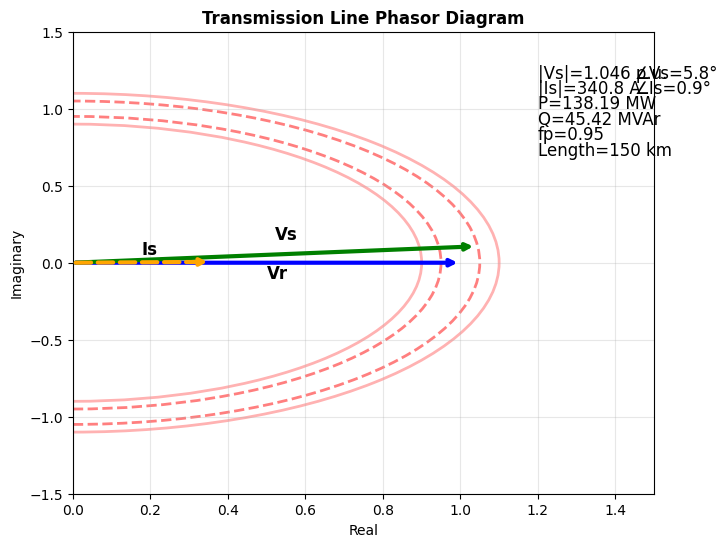

In [4]:

# ----------------------------
# ipywidgets UI
# ----------------------------
def make_transmission_line_widget():
    # Controls
    s_x  = widgets.IntSlider(value=150, min=120, max=200, step=5, description='Line Length (km):', continuous_update=False)
    s_vr = widgets.FloatSlider(value=1.0, min=0.9, max=1.1, step=0.05, readout_format='.2f',
                               description='Vr (p.u.):', continuous_update=False)
    s_pn = widgets.FloatSlider(value=1.0, min=1.0, max=3.0, step=0.1, readout_format='.1f',
                               description='Loading (p.u.):', continuous_update=False)
    s_fp = widgets.FloatSlider(value=0.95, min=0.8, max=1.0, step=0.05, readout_format='.2f',
                               description='Power Factor:', continuous_update=False)
    r_i  = widgets.RadioButtons(options=[('Lagging', -1), ('Leading', 1)], value=-1, description='PF Type:')

    controls = widgets.VBox([s_x, s_vr, s_pn, s_fp, r_i], layout=widgets.Layout(width='330px'))

    # Plot area and numeric readout
    fig, ax = plt.subplots(figsize=(7.5, 6.0))
    out_plot = widgets.Output()
    out_text = widgets.HTML()

    # Initial draw
    with out_plot:
        qLT_plot(ax, icb=inom, z=z, y=y, x_km=s_x.value, Vb=Vn,
                 Vr=s_vr.value, pn=s_pn.value, fp=s_fp.value, i_sign=r_i.value)
        display(fig)
    pSend, pRec, losses = calculate_losses(s_x.value, Vn, s_vr.value, s_pn.value, s_fp.value, r_i.value)
    out_text.value = f"<b>Losses:</b> P_send = {pSend:.3f} MW | P_recv = {pRec:.3f} MW | Losses = {losses:.3f} MW"

    # Update handler
    def update(change=None):
        qLT_plot(ax, icb=inom, z=z, y=y, x_km=s_x.value, Vb=Vn,
                 Vr=s_vr.value, pn=s_pn.value, fp=s_fp.value, i_sign=r_i.value)
        with out_plot:
            out_plot.clear_output(wait=True)
            display(fig)
        pSend, pRec, losses = calculate_losses(s_x.value, Vn, s_vr.value, s_pn.value, s_fp.value, r_i.value)
        out_text.value = f"<b>Losses:</b> P_send = {pSend:.3f} MW | P_recv = {pRec:.3f} MW | Losses = {losses:.3f} MW"

    # Wire events
    for w in (s_x, s_vr, s_pn, s_fp, r_i):
        w.observe(update, names='value')

    right = widgets.VBox([out_plot, out_text])
    ui = widgets.HBox([controls, right])
    return ui

# Build and display the widget
ui = make_transmission_line_widget()
display(ui)
